In [ ]:
# project 1st file 기본 전처리(robustScaler) 후 모델 돌려보기 2025.11.26
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os


import importlib
from utils import preprocessing
importlib.reload(preprocessing)

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 

In [64]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)


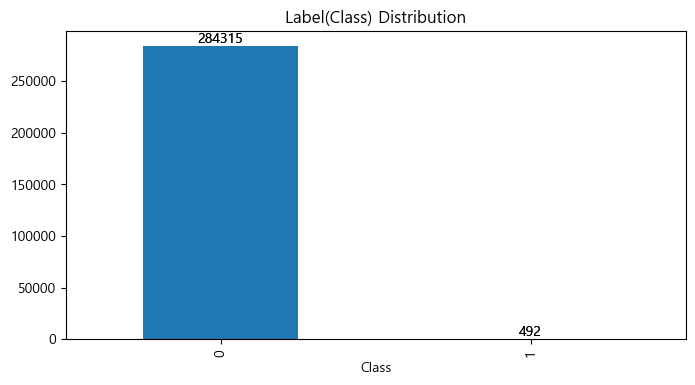

In [16]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False, isGraph=True)


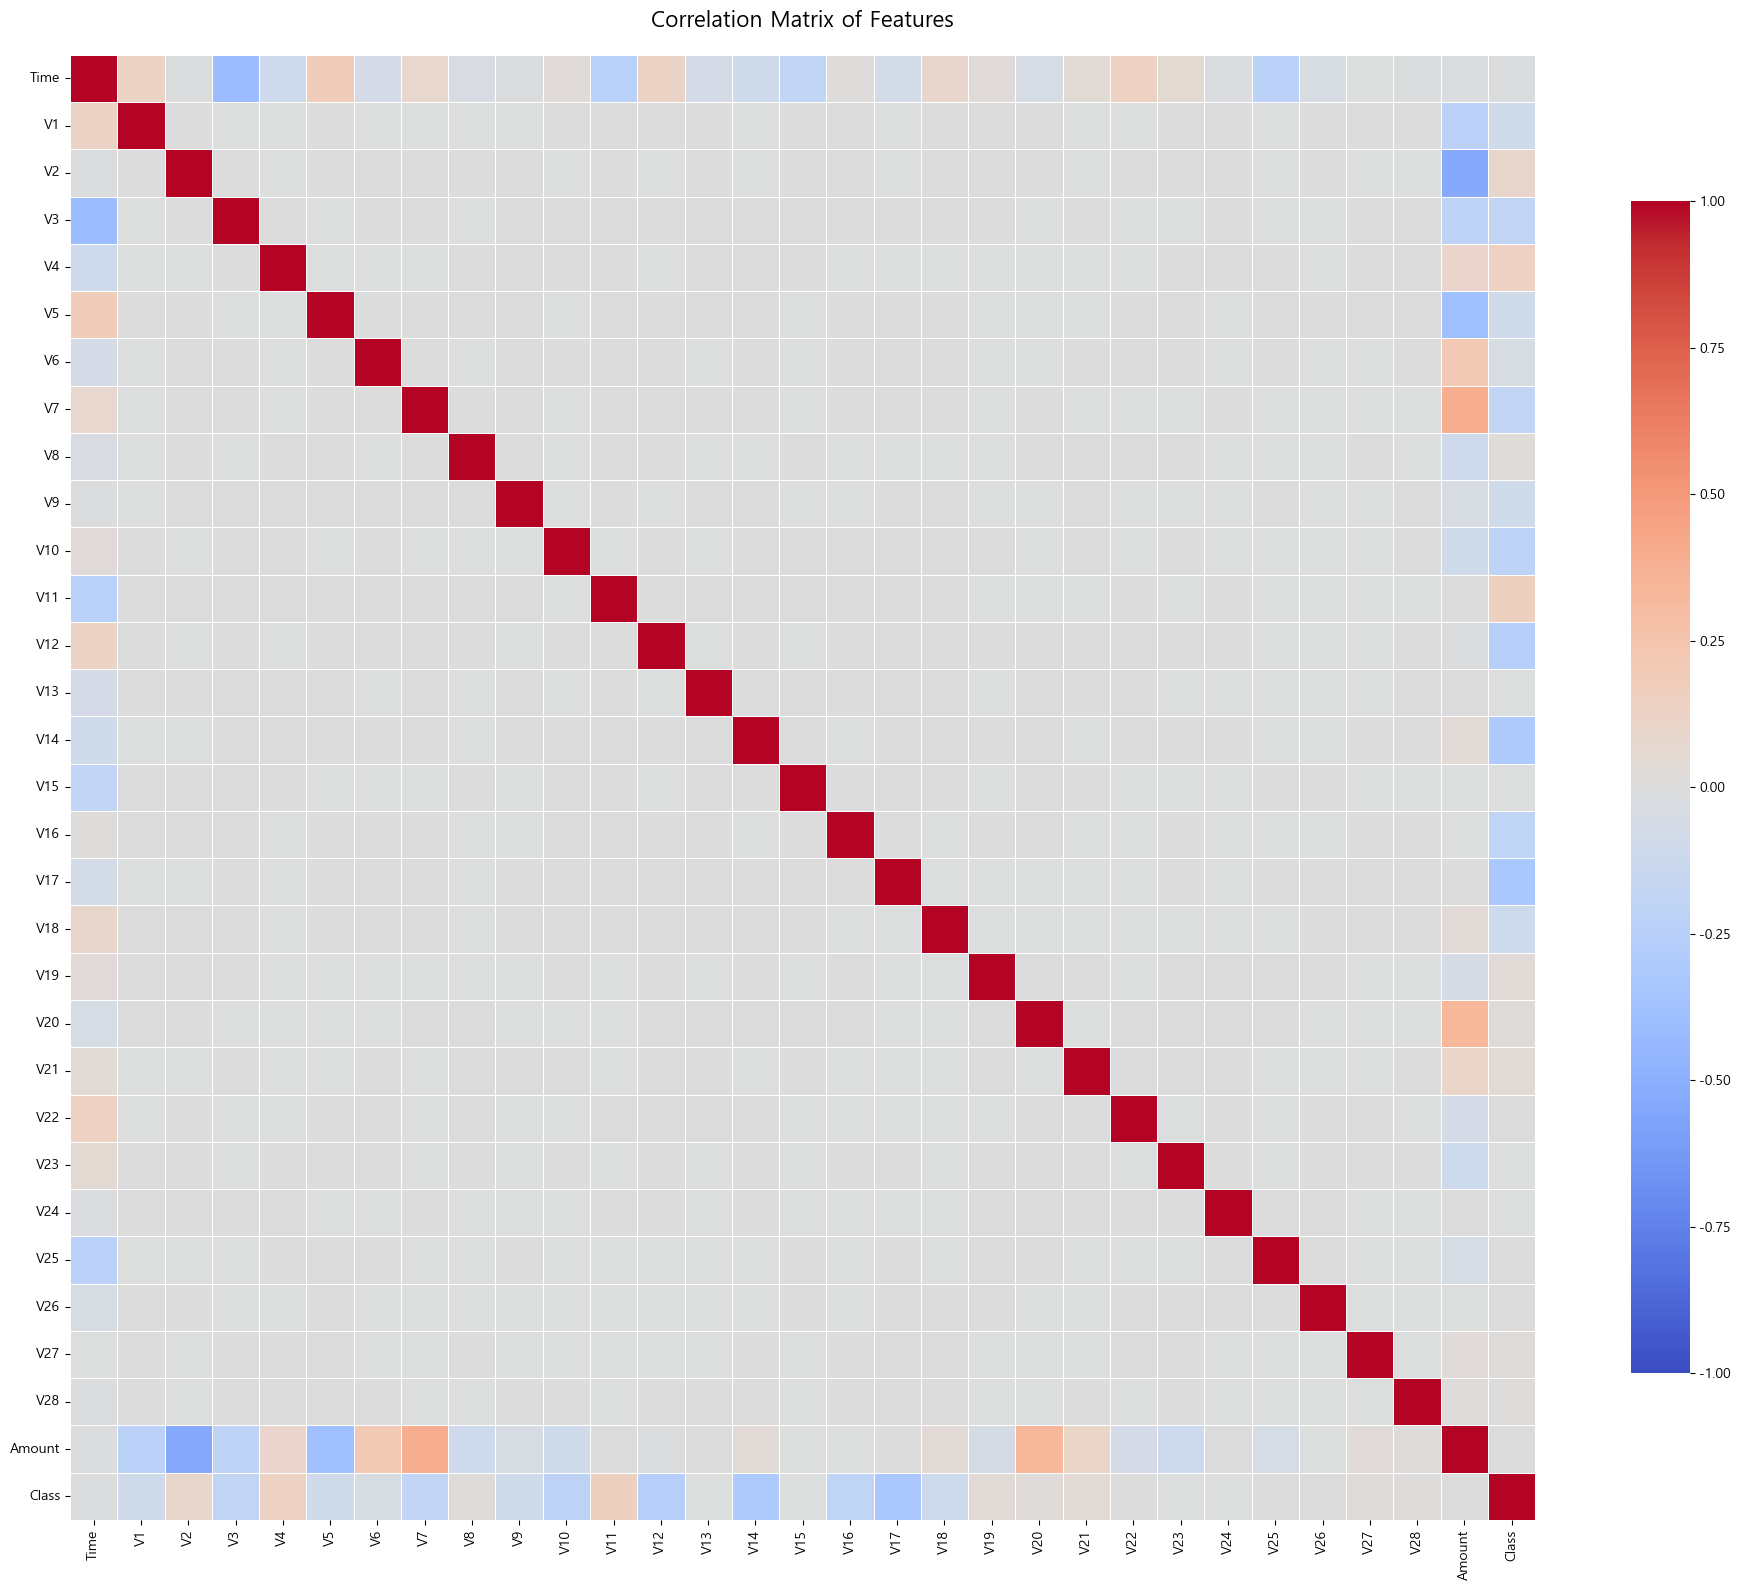

상관관계 통계 요약
평균 상관계수: -0.0065
최대 상관계수: 0.3973
최소 상관계수: -0.5314
표준편차: 0.0637

높은 상관관계 변수 쌍 (|correlation| > 0.7)
높은 상관관계 쌍이 발견되지 않았습니다.

'Time'와 상관관계가 높은 변수들 (상위 10개)

V3     0.419618
V11    0.247689
V25    0.233083
V15    0.183453
V5     0.173072
V22    0.144059
V12    0.124348
V1     0.117396
V4     0.105260
V14    0.098757

결과가 파일로 저장되었습니다: ../results/CorrWithTime_2025_1126.txt


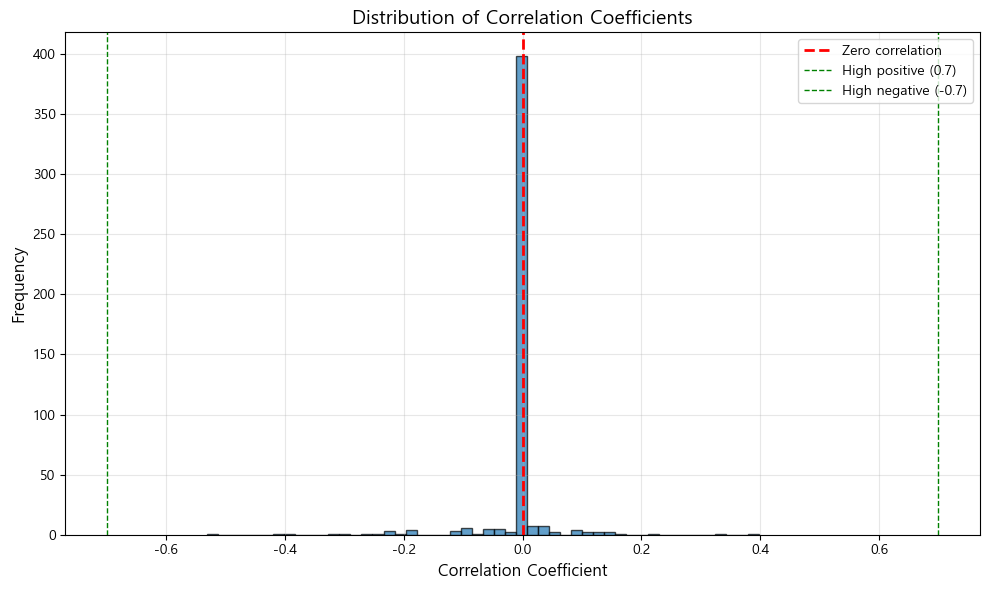

In [79]:
# 상관관계 시각화 시도
pp.corrGraph(df)    

In [ ]:
# X_features, y_target = pp.split_features_target(df, cols='Time', target_col='Class')
# df_desc_org = uu.get_outlier(X_features)


In [ ]:
# df_desc_org
# outlier_cols = df_desc_org[df_desc_org['OutlierCount'] > 10000].index.to_list()[:-1]
# outlier_cols

['V2',
 'V4',
 'V5',
 'V6',
 'V8',
 'V12',
 'V14',
 'V19',
 'V20',
 'V21',
 'V23',
 'V27',
 'V28']

In [ ]:
# df['Amount'].value_counts()
# df['Amount'].value_counts(normalize=True)
# df[df['Amount']> 184]['Amount']

2          378.66
20         231.71
51        1402.95
64         243.66
85         200.01
           ...   
284735     381.05
284748     220.28
284753     337.54
284757     200.00
284806     217.00
Name: Amount, Length: 31959, dtype: float64

In [80]:
# 2. Data전처리
# Amount와 Time 스케일링 (V1-V28은 이미 PCA 처리됨)
df_robust_scaled = pp.robustScaler(df)

✅ 'Amount' 스케일링 완료 → 'Amount_scaled'
✅ 'Time' 스케일링 완료 → 'Time_scaled'

🗑️  원본 컬럼 제거: ['Amount', 'Time']

✅ 스케일링 완료: 2개 컬럼
   최종 shape: (284807, 31)


In [81]:
## 데이터 
X_features, y_target = pp.split_features_target(df_robust_scaled)
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

['V2',
 'V4',
 'V5',
 'V6',
 'V8',
 'V12',
 'V14',
 'V19',
 'V20',
 'V21',
 'V23',
 'V27',
 'V28']

In [ ]:

outlier_index = get_outlier_index(df_sacled, column=outlier_cols)

In [53]:

print(f"outlier_index cnt: {len(outlier_index)}, rate:{(len(outlier_index) / df_sacled.shape[0]) * 100}%")

outlier_index cnt: 492, rate:0.1727485630620034%


In [ ]:
## 모델 학습
from xgboost import XGBClassifier
# scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), random_state=42
XGBoost = XGBClassifier()
